In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
employee_attrition = pd.read_csv("Downloads/Data Science Basic/HR-Employee-Attrition.csv")
print(employee_attrition)

      Age Attrition     BusinessTravel  DailyRate              Department  \
0      41       Yes      Travel_Rarely       1102                   Sales   
1      49        No  Travel_Frequently        279  Research & Development   
2      37       Yes      Travel_Rarely       1373  Research & Development   
3      33        No  Travel_Frequently       1392  Research & Development   
4      27        No      Travel_Rarely        591  Research & Development   
...   ...       ...                ...        ...                     ...   
1465   36        No  Travel_Frequently        884  Research & Development   
1466   39        No      Travel_Rarely        613  Research & Development   
1467   27        No      Travel_Rarely        155  Research & Development   
1468   49        No  Travel_Frequently       1023                   Sales   
1469   34        No      Travel_Rarely        628  Research & Development   

      DistanceFromHome  Education EducationField  EmployeeCount  \
0       

In [6]:
print(employee_attrition.head())
print(employee_attrition.info())
print(employee_attrition.describe())

   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical              1               7   

   ...  RelationshipSatisfaction StandardHours  StockOptionLevel  \
0  ...

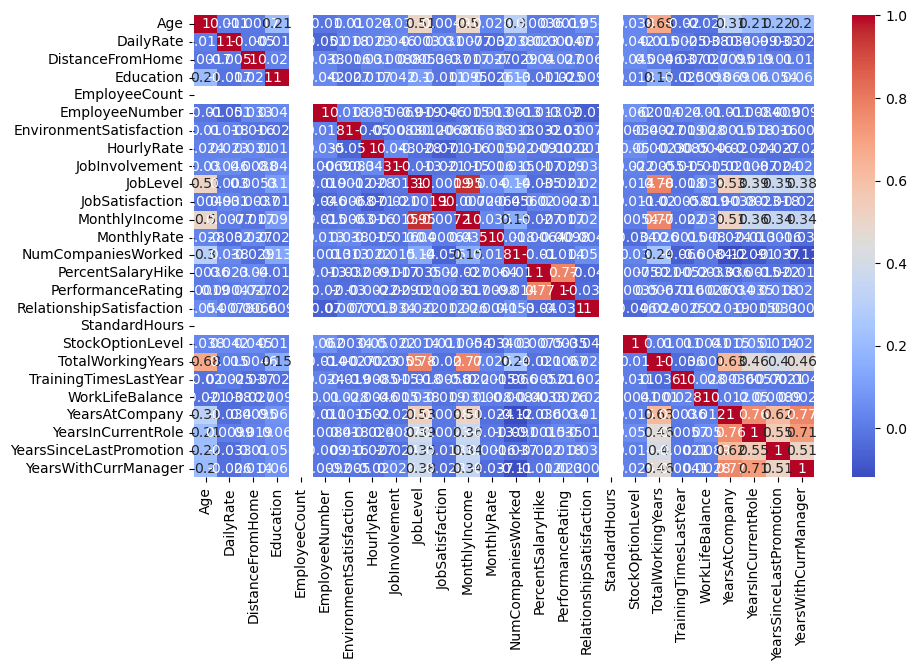

In [8]:
plt.figure(figsize=(10,6))
sns.heatmap(employee_attrition.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')
plt.show()

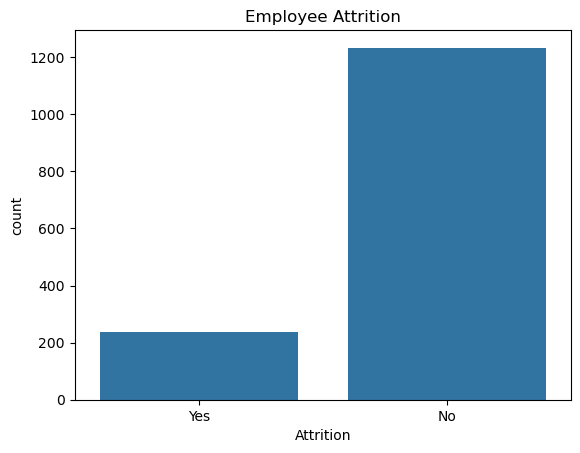

In [14]:
sns.countplot(x='Attrition',data=employee_attrition)
plt.title("Employee Attrition")
plt.show()

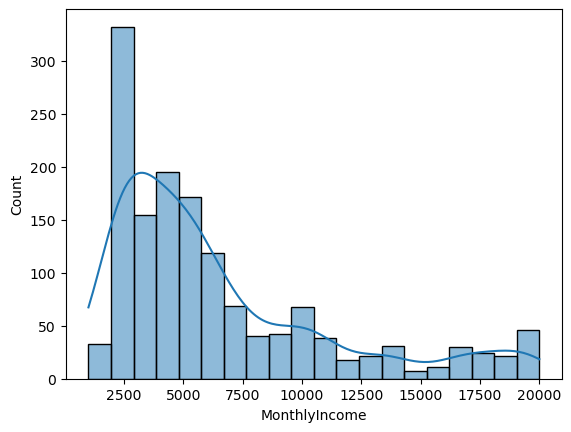

In [17]:
sns.histplot(employee_attrition['MonthlyIncome'], kde=True)
plt.show()

##### 1. Which Department Has the Highest Attrition?
Identify departments where employees leave most frequently

Attrition                No  Yes
Department                      
Human Resources          51   12
Research & Development  828  133
Sales                   354   92


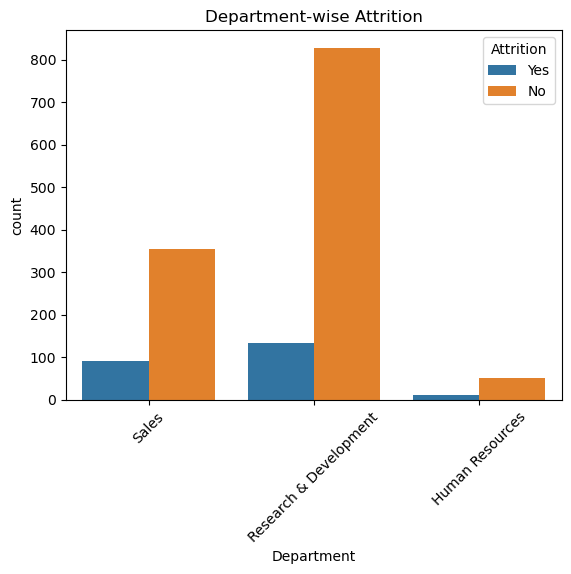

In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
dept_attrition = pd.crosstab(
    employee_attrition['Department'],
    employee_attrition['Attrition']
)
print(dept_attrition)
sns.countplot(x='Department', hue='Attrition', data=employee_attrition)
plt.title("Department-wise Attrition")
plt.xticks(rotation=45)
plt.show()

##### 2. Does Overtime Affect Attrition?

Determine whether employees working overtime are more likely to leave.

In [22]:
overtime_attrition = pd.crosstab(
    employee_attrition['OverTime'],
    employee_attrition['Attrition'],
    normalize='index'
) * 100

print(overtime_attrition)

Attrition         No        Yes
OverTime                       
No         89.563567  10.436433
Yes        69.471154  30.528846


##### 3. Relationship Between Salary and Experience

Understand whether salary increases with experience.

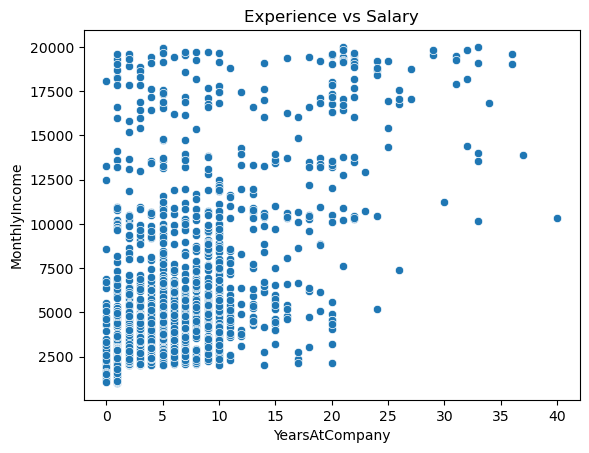

In [23]:
sns.scatterplot(
    x='YearsAtCompany',
    y='MonthlyIncome',
    data=employee_attrition
)

plt.title("Experience vs Salary")
plt.show()

In [24]:
employee_attrition[['YearsAtCompany','MonthlyIncome']].corr()

,YearsAtCompany,MonthlyIncome
YearsAtCompany,1.000000,0.514285
MonthlyIncome,0.514285,1.000000


##### 4. Gender Distribution

Analyze workforce diversity.

Gender
Male      882
Female    588
Name: count, dtype: int64


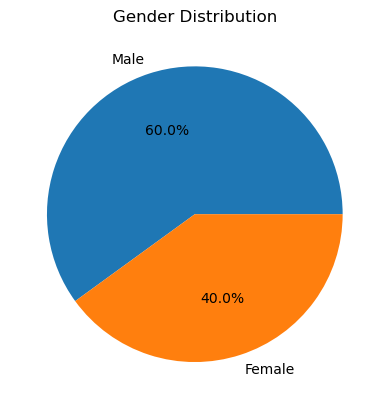

In [25]:
gender_count = employee_attrition['Gender'].value_counts()

print(gender_count)

plt.pie(
    gender_count,
    labels=gender_count.index,
    autopct='%1.1f%%'
)

plt.title("Gender Distribution")
plt.show()

##### 5. Average Salary by Department

Compare department-wise compensation.

Department
Human Resources           6654.507937
Research & Development    6281.252862
Sales                     6959.172646
Name: MonthlyIncome, dtype: float64


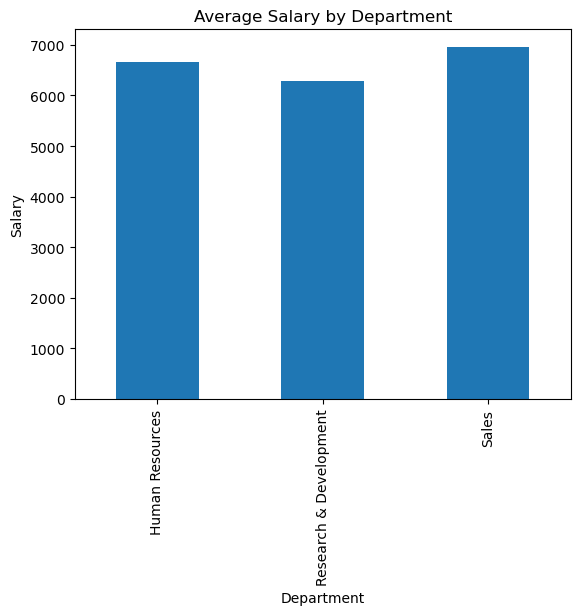

In [26]:
avg_salary = employee_attrition.groupby(
    'Department'
)['MonthlyIncome'].mean()

print(avg_salary)

avg_salary.plot(
    kind='bar'
)

plt.title("Average Salary by Department")
plt.ylabel("Salary")
plt.show()